In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

In [ ]:
digits = load_digits()
X = digits.data

# Normalize (0–16 → 0–1)
X = X / 16.0

# Split
x_train, x_test = train_test_split(X, test_size=0.2, random_state=42)

In [ ]:
input_dim = 64
latent_dim = 8   # 🔥 2D latent space

In [ ]:
inputs = layers.Input(shape=(input_dim,))

h = layers.Dense(32, activation='relu')(inputs)

z_mean = layers.Dense(latent_dim, name="z_mean")(h)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(h)

In [ ]:
def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])

In [ ]:
encoder = Model(inputs, [z_mean, z_log_var, z], name="encoder")

In [ ]:
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(32, activation='relu')(latent_inputs)
outputs = layers.Dense(input_dim, activation='sigmoid')(x)

decoder = Model(latent_inputs, outputs, name="decoder")

In [ ]:
class VAE(tf.keras.Model):   # (now behaves like Autoencoder)
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        _, _, z = self.encoder(inputs)   # only use z
        return self.decoder(z)

    def train_step(self, data):
        if isinstance(data, tuple):
            x = data[0]
        else:
            x = data

        with tf.GradientTape() as tape:
            _, _, z = self.encoder(x)
            reconstruction = self.decoder(z)

            # 🔥 MSE Loss (improved version)
            recon_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.square(x - reconstruction), # Changed to element-wise square
                    axis=1
                )
            )

            total_loss = recon_loss   # ✅ no KL

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return {
            "loss": total_loss,
            "reconstruction_loss": recon_loss,
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            x = data[0]
        else:
            x = data

        _, _, z = self.encoder(x)
        reconstruction = self.decoder(z)

        recon_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.square(x - reconstruction), # Changed to element-wise square
                axis=1
            )
        )

        return {
            "loss": recon_loss,
            "reconstruction_loss": recon_loss,
        }


In [ ]:
vae = VAE(encoder, decoder)
vae.compile(optimizer='adam')

vae.fit(
    x_train,
    epochs=5,
    batch_size=256,
    validation_data=(x_test, x_test)
)

Epoch 1/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 12.0128 - reconstruction_loss: 12.0128 - val_loss: 11.7002 - val_reconstruction_loss: 11.7002
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 11.3459 - reconstruction_loss: 11.3459 - val_loss: 11.1170 - val_reconstruction_loss: 11.1170
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 10.7281 - reconstruction_loss: 10.7281 - val_loss: 10.5502 - val_reconstruction_loss: 10.5502
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 10.1386 - reconstruction_loss: 10.1386 - val_loss: 9.9339 - val_reconstruction_loss: 9.9339
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 9.4531 - reconstruction_loss: 9.4531 - val_loss: 9.2350 - val_reconstruction_loss: 9.2350


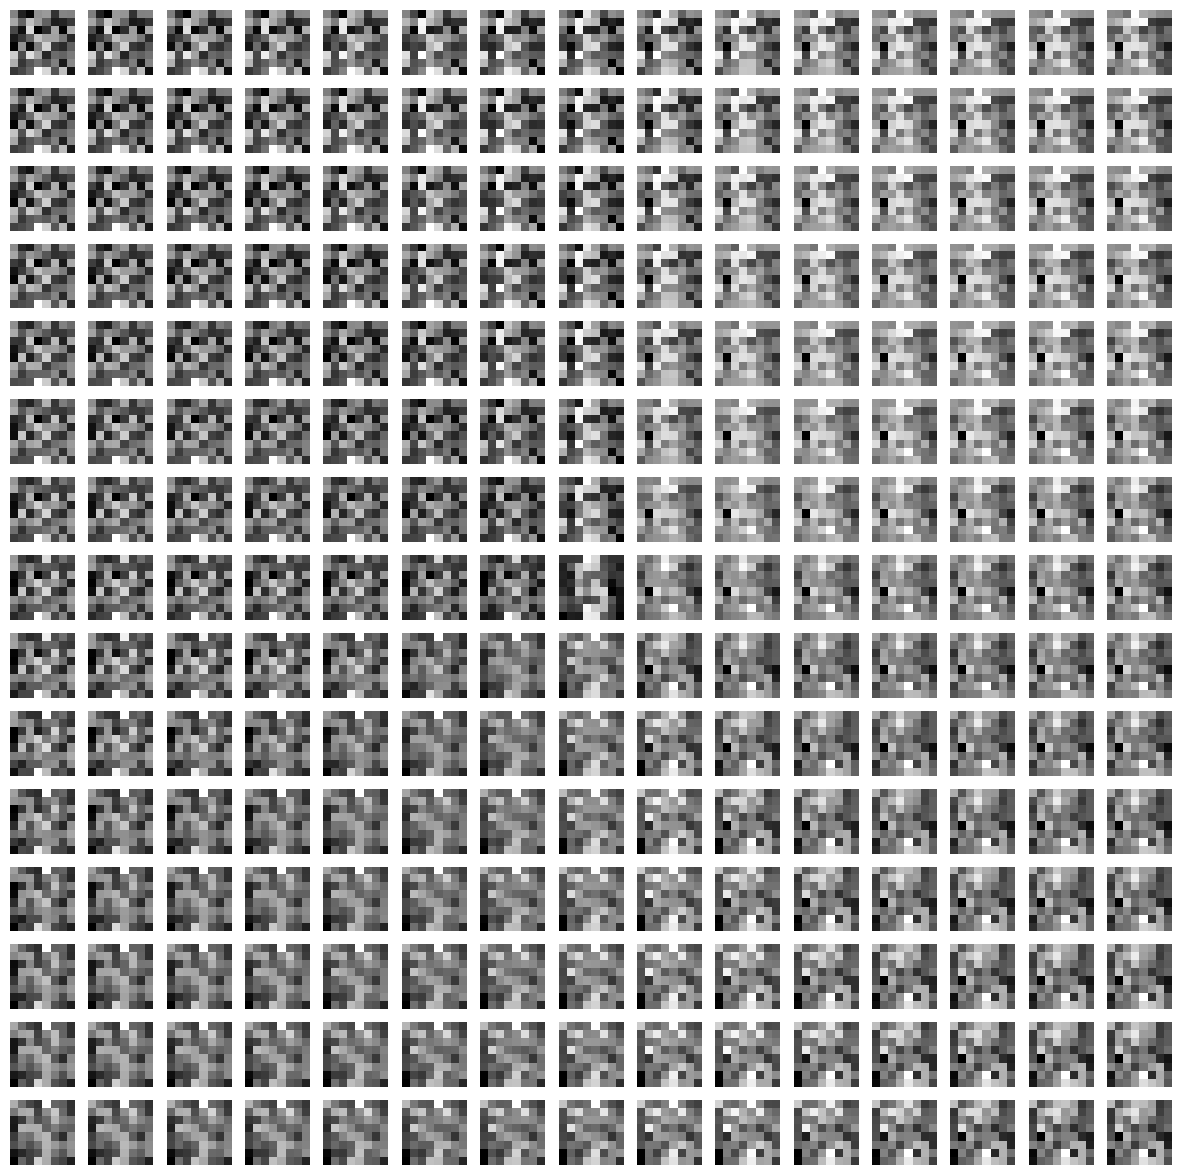

In [ ]:
latent_dim = 8  # already set

# Define the grid for the latent space
# Assuming the first two dimensions of the latent space are most relevant for visualization
n_grid = 15 # Number of points to sample along each dimension
grid_x = np.linspace(-4, 4, n_grid) # Adjust range as needed based on latent space distribution
grid_y = np.linspace(-4, 4, n_grid)

n = n_grid # Set n to match the grid dimensions

plt.figure(figsize=(n, n)) # Adjust figure size dynamically

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):

        z_sample = np.zeros((1, latent_dim))  # 🔥 8D vector
        z_sample[0, 0] = xi   # vary dim 1
        z_sample[0, 1] = yi   # vary dim 2

        x_decoded = decoder.predict(z_sample, verbose=0)
        digit = x_decoded[0].reshape(8, 8)

        plt.subplot(n, n, i * n + j + 1)
        plt.imshow(digit, cmap='gray')
        plt.axis('off')

plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


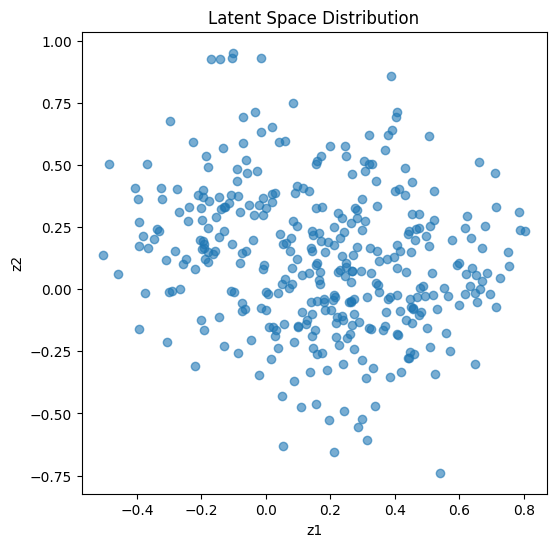

In [ ]:
z_mean, _, _ = encoder.predict(x_test)

plt.figure(figsize=(6, 6))
plt.scatter(z_mean[:, 0], z_mean[:, 1], alpha=0.6)
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Latent Space Distribution")
plt.show()

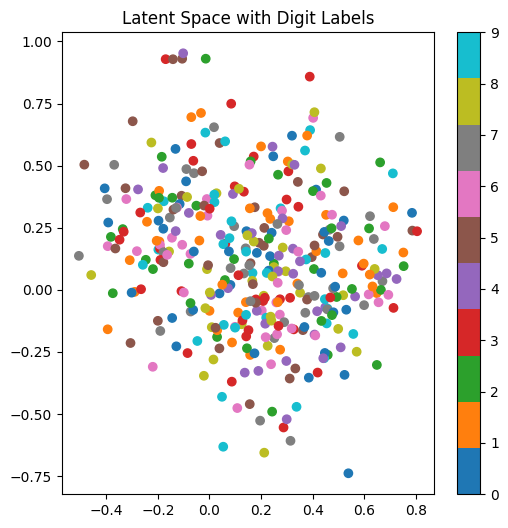

In [ ]:
y_test = load_digits().target
y_test = y_test[:len(z_mean)]  # match size

plt.figure(figsize=(6, 6))
scatter = plt.scatter(z_mean[:, 0], z_mean[:, 1], c=y_test, cmap='tab10')
plt.colorbar(scatter)
plt.title("Latent Space with Digit Labels")
plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


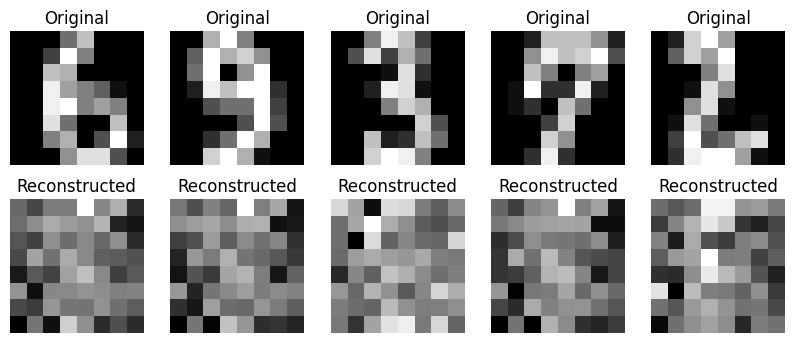

In [ ]:
reconstructed = vae.predict(x_test)

n = 5
plt.figure(figsize=(10, 4))

for i in range(n):
    # Original
    plt.subplot(2, n, i+1)
    plt.imshow(x_test[i].reshape(8,8), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    plt.subplot(2, n, i+n+1)
    plt.imshow(reconstructed[i].reshape(8,8), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


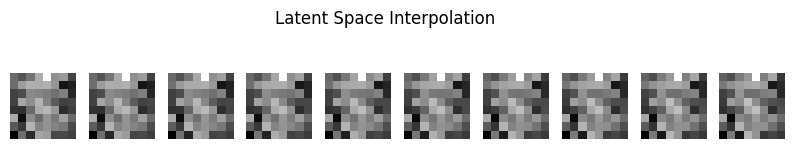

In [ ]:
# Pick two images
img1 = x_test[0]
img2 = x_test[1]

z1, _, _ = encoder.predict(img1.reshape(1, -1))
z2, _, _ = encoder.predict(img2.reshape(1, -1))

alphas = np.linspace(0, 1, 10)

plt.figure(figsize=(10, 2))

for i, alpha in enumerate(alphas):
    z_interp = (1 - alpha) * z1 + alpha * z2
    decoded = decoder.predict(z_interp, verbose=0)

    plt.subplot(1, 10, i+1)
    plt.imshow(decoded[0].reshape(8,8), cmap='gray')
    plt.axis('off')

plt.suptitle("Latent Space Interpolation")
plt.show()